In [31]:
import pandas as pd
from pathlib import Path

test = "1"
index = "6"
parameter= "translation_z"
scene = "cornell"
camera = "camera1"
csv_path = Path(f"Output/{scene}/{parameter}/{index}/{test}/{camera}_{parameter}_sweep.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)

required_columns = {f"{parameter}", "loss", "analytic_grad", "fd_grad"}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

df.head()

,iter,translation_z,loss,analytic_grad,fd_grad,fd_kind,fd_epsilon
0,0,0.20,0.003575,-0.008370,-0.002812,0,0.005
1,1,0.25,0.003478,-0.002530,-0.001279,0,0.005
2,2,0.30,0.003459,-0.001212,0.000848,0,0.005
3,3,0.35,0.003546,0.000177,0.002894,0,0.005
4,4,0.40,0.003681,-0.002804,0.002663,0,0.005


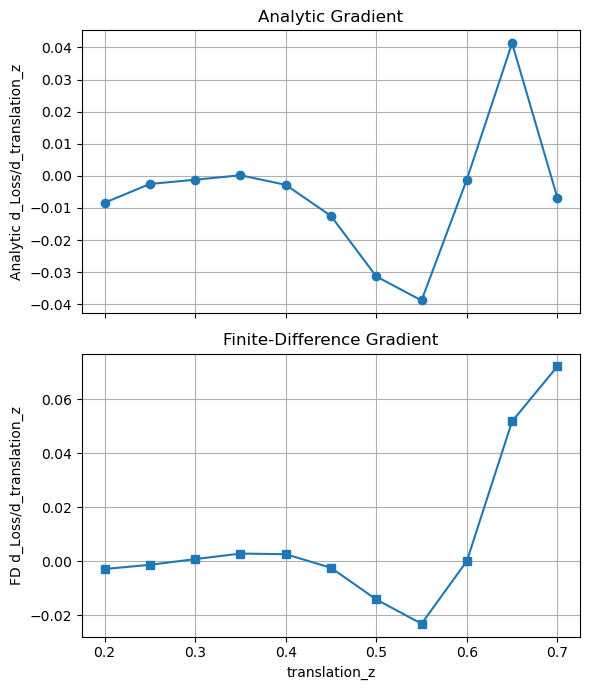

PosixPath('Output/cornell/translation_z/6/1/camera1_translation_z_sweep_grad_subplots.png')

In [32]:

import matplotlib.pyplot as plt

NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7), sharex=True)

# --- Top: Analytic ---
axes[0].plot(df[f"{parameter}"], df["analytic_grad"], marker="o")
axes[0].set_ylabel(f"Analytic d_Loss/d_{parameter}")
axes[0].set_title("Analytic Gradient")
axes[0].grid(True)

# --- Bottom: Finite Difference ---
axes[1].plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s")
axes[1].set_xlabel(f"{parameter}")
axes[1].set_ylabel(f"FD d_Loss/d_{parameter}")
axes[1].set_title("Finite-Difference Gradient")
axes[1].grid(True)

output_png = csv_path.with_name(csv_path.stem + "_grad_subplots.png")
plt.tight_layout()
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

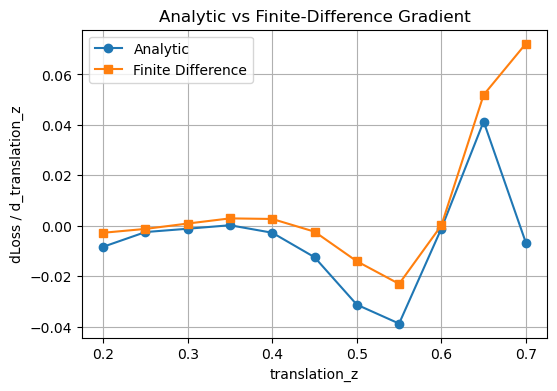

PosixPath('Output/cornell/translation_z/6/1/camera1_translation_z_sweep_grad_compare.png')

In [33]:
NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

plt.figure(figsize=(6, 4))

plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d_{parameter}")
plt.title("Analytic vs Finite-Difference Gradient")
plt.grid(True)
plt.legend()

output_png = csv_path.with_name(csv_path.stem + "_grad_compare.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()
output_png

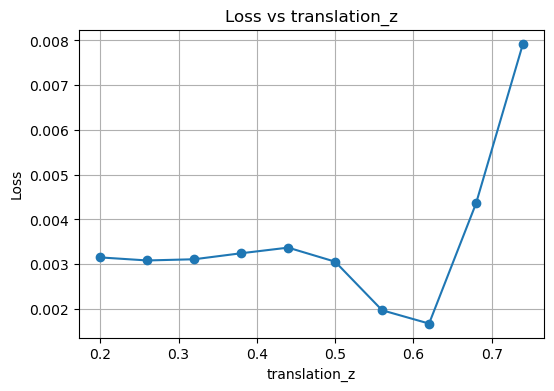

PosixPath('Output/cornell/translation_z/6/1/camera1_translation_z_sweep_loss.png')

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["loss"], marker="o")
plt.xlabel(f"{parameter}")
plt.ylabel("Loss")
plt.title(f"Loss vs {parameter}")
plt.grid(True)

output_png = csv_path.with_name(csv_path.stem + "_loss.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

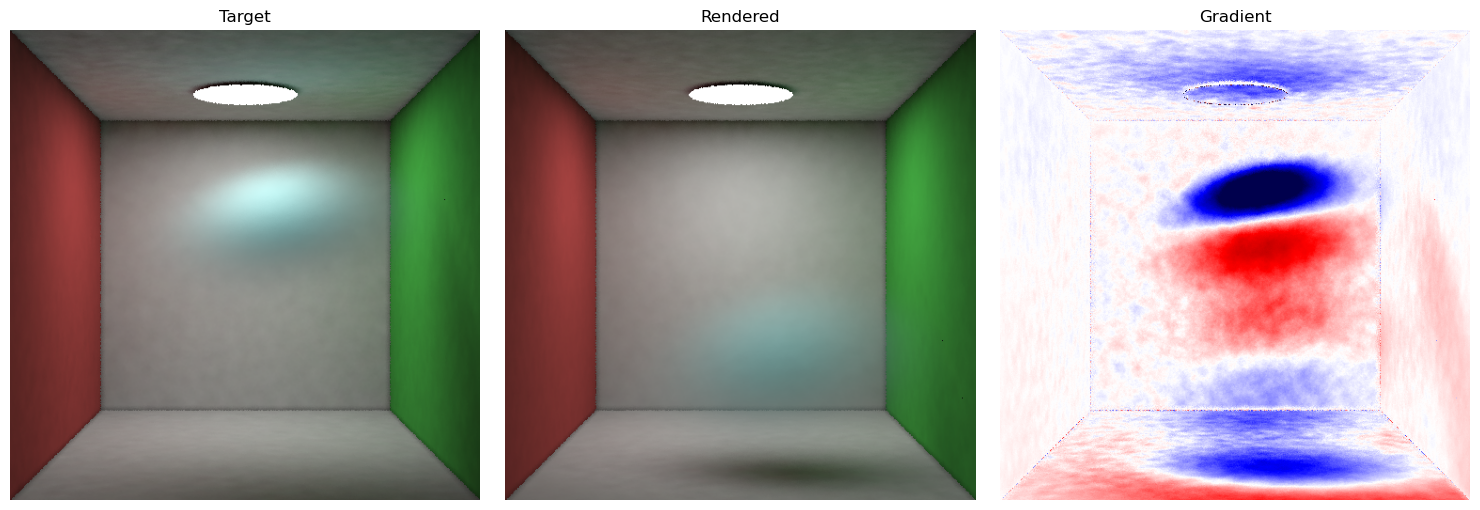

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Paths
iteration = 1
target_image = Path(f"Output/{scene}/{parameter}/{camera}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{index}/{test}/rendered/{iteration}_{camera}.png")
grad_image = Path(f"Output/{scene}/{parameter}/{index}/{test}/grad/{iteration}_{camera}.png")



# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)
img_grad = Image.open(grad_image)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

axes[2].imshow(img_grad)
axes[2].set_title("Gradient")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [10]:
analytic_gradients = df["analytic_grad"].to_numpy(dtype=float)
numerical_gradients = df[NUMERICAL_COLUMN].to_numpy(dtype=float)

relative_errors = np.abs(analytic_gradients - numerical_gradients) / np.maximum(
    1e-12, np.abs(analytic_gradients) + np.abs(numerical_gradients)
)

for parameter_value, analytic_gradient, numerical_gradient, relative_error in zip(
    df[parameter],
    analytic_gradients,
    numerical_gradients,
    relative_errors,
):
    print(
        f"{parameter}={parameter_value:.6f}  "
        f"analytic={analytic_gradient:+.6e}  "
        f"numerical={numerical_gradient:+.6e}  "
        f"rel_err={relative_error:.6%}"
    )

translation_z=0.200000  analytic=-1.465532e-03  numerical=-1.423107e-03  rel_err=1.468672%
translation_z=0.260000  analytic=-4.541976e-04  numerical=-4.381640e-04  rel_err=1.796756%
translation_z=0.320000  analytic=+1.453647e-03  numerical=+1.452491e-03  rel_err=0.039806%
translation_z=0.380000  analytic=+2.604628e-03  numerical=+2.816971e-03  rel_err=3.916615%
translation_z=0.440000  analytic=-5.251262e-04  numerical=+8.435454e-05  rel_err=100.000000%
translation_z=0.500000  analytic=-1.283465e-02  numerical=-1.216363e-02  rel_err=2.684262%
translation_z=0.560000  analytic=-2.245622e-02  numerical=-1.979771e-02  rel_err=6.291747%
translation_z=0.620000  analytic=+1.885111e-02  numerical=+1.894510e-02  rel_err=0.248688%
translation_z=0.680000  analytic=+6.220880e-02  numerical=+6.171791e-02  rel_err=0.396118%
translation_z=0.740000  analytic=+5.658973e-02  numerical=+5.351822e-02  rel_err=2.789549%


Output/cornell/translation_z/6/1/rendered/camera2/0_camera2.png


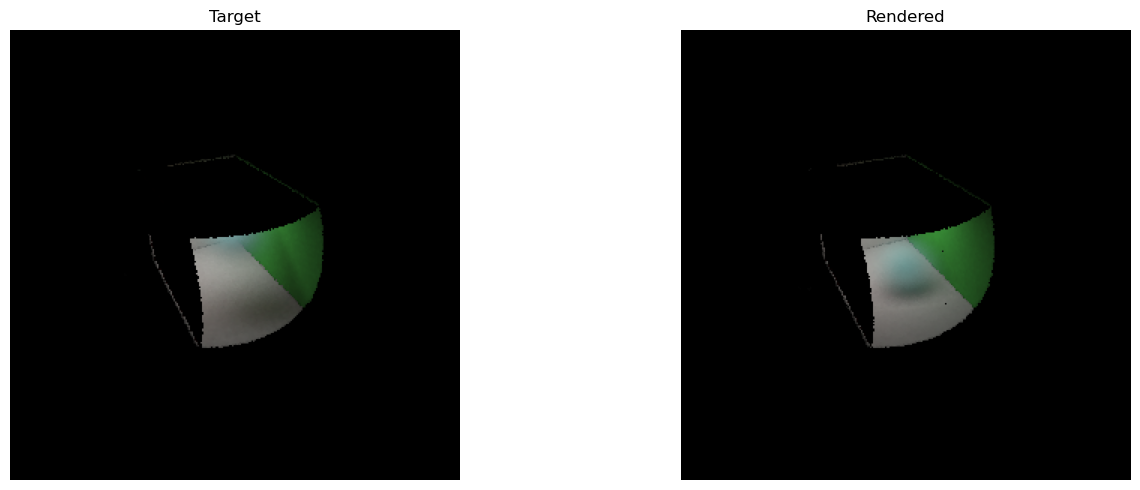

In [7]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

camera_2 = "camera2"
# Paths
iteration = 0
target_image = Path(f"Output/{scene}/{parameter}/{camera_2}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{index}/{test}/rendered/{camera_2}/{iteration}_{camera_2}.png")

print(rendered_test)

# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

plt.tight_layout()
plt.show()

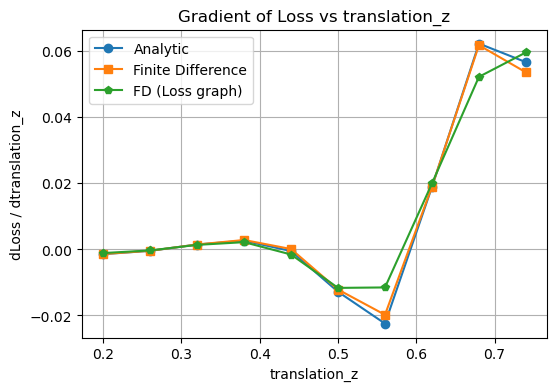

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = df[f"{parameter}"].to_numpy(dtype=np.float64)
y = df["loss"].to_numpy(dtype=np.float64)

# Numerical gradient d(loss) / d(parameter)
loss_gradient = np.gradient(y, x)

# Store it in the dataframe
df["loss_gradient"] = loss_gradient


# Plot gradient
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")
plt.plot(x, loss_gradient, marker="p", label="FD (Loss graph)")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d{parameter}")
plt.title(f"Gradient of Loss vs {parameter}")
plt.grid(True)
plt.legend()

output_gradient_png = csv_path.with_name(csv_path.stem + "_loss_gradient.png")
plt.savefig(output_gradient_png, dpi=200, bbox_inches="tight")
plt.show()